<!-- NINO26-CABECALHO v1 -->
# 3I — Interpretação integrada da Fase 3

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3I`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Sintetiza 3A-3H/3K num conjunto de precursores com antecedência e numa leitura cautelosa para 2025/26 — a evidência que entra no parecer do mecanismo.

## Pergunta
Qual conjunto de variáveis explica o aquecimento máximo com antecedência e qual é a leitura prospectiva cautelosa para 2025/26?

## Desafio (hipótese a testar)
A projeção condicional deve ser rotulada como exploratória, com IC largo declarado e sem vazamento de informação futura.

## Metodologia (com referências)
Consolidação dos precursores, antecipação do pico e projeção condicional com validação nested LOO (Cawley & Talbot, 2010; complexidade de ENSO em Timmermann et al., 2018; Cai et al., 2020).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3I01", fase=3, bloco="I",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3I_interpretacao_integrada.ipynb",
                 fontes={"<tabela>": df})   # -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3I01` | `Fig_3I01.png` | `Fig_3I01/` | síntese para o parecer |
| `Fig_3I02` | `Fig_3I02.png` | `Fig_3I02/` | antecipação do pico |
| `Fig_3I03` | `Fig_3I03.png` | `Fig_3I03/` | projeção condicional nested |
| `Fig_3I04` | `Fig_3I04.png` | `Fig_3I04/` | galeria de figuras da Fase 3 |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; validação por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u

w = pd.read_csv(u.FEAT/'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
d3 = pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
e3 = pd.read_csv(u.STATS/'phase3E_sensibilidade_resumo.csv').set_index('variavel')
print('Variaveis no parecer (todas Pacifico):', list(d3.index))
bloco = {
    'tilt_m':'recarga/subsuperficie', 'ssh_m':'recarga/subsuperficie', 'ohc_0_300':'recarga/subsuperficie',
    'ohc_0_700':'recarga/subsuperficie', 'd20_m':'recarga/subsuperficie', 'wwv':'recarga/subsuperficie',
    'tau_x_anom_nino34_pa':'vento/acoplamento',
}
rows = []
for v in d3.index:
    lag = int(d3.loc[v, 'lag_semanas'])
    r = float(d3.loc[v, 'r'])
    if lag >= 12:
        papel = 'precursor antecipado'
        uso = 'candidato de antecedencia; validar no nested LOO'
    elif lag > 0:
        papel = 'precursor curto/medio prazo'
        uso = 'apoio diagnostico'
    else:
        papel = 'estado simultaneo/acoplado'
        uso = 'diagnostico de estado'
    sens = e3.loc[v] if v in e3.index else pd.Series(dtype=float)
    rows.append({
        'variavel':v, 'rotulo':u.var_label(v, short=True), 'bloco':bloco.get(v, '-'),
        'lag_semanas':lag, 'r':round(r, 3), 'abs_r':round(abs(r), 3),
        'bootstrap_ic95_inf': sens.get('bootstrap_ic95_inf_envelope', np.nan),
        'bootstrap_ic95_sup': sens.get('bootstrap_ic95_sup_envelope', np.nan),
        'loo_max_delta_r': sens.get('loo_max_delta_r', np.nan),
        'loo_evento_maior_influencia': sens.get('loo_evento_maior_influencia', ''),
        'papel':papel, 'uso_parecer':uso,
    })
conc = pd.DataFrame(rows).sort_values(['abs_r','lag_semanas'], ascending=[False, False])
u.save_table(conc, 'phase3I_conclusoes_decisao.csv', index=False)
antecip = conc.assign(horizonte=np.select([conc['lag_semanas']>=26, conc['lag_semanas']>=12, conc['lag_semanas']>0], ['longo (>=6 meses)','medio (3-6 meses)','curto (<3 meses)'], default='simultaneo'))
antecip['interpreta_para_2026'] = antecip.apply(lambda r: 'candidato; validar por nested LOO' if r['lag_semanas']>=12 else ('usar como estado/acoplamento atual' if r['lag_semanas']<=6 else 'apoio diagnostico'), axis=1)
u.save_table(antecip, 'phase3I_conjunto_antecipacao_pico.csv', index=False)
print(antecip[['rotulo','bloco','lag_semanas','r','bootstrap_ic95_inf','bootstrap_ic95_sup','loo_max_delta_r','horizonte','interpreta_para_2026']].to_string(index=False))


Variaveis no parecer (todas Pacifico): ['ohc_0_100', 't50m', 'tilt_m', 'ssh_m', 'tcwv_anom', 'tilt_slope', 'ohc_0_300', 'sshf_anom', 'ohc_0_700', 't100m', 'omega850_anom', 'u850_anom', 'ssr_anom', 'u200_anom', 'omega500_anom', 'd20_m', 't300m', 'wwv', 'slhf_anom', 'u10_anom', 'tau_x_anom_nino34_pa', 't150m', 'str_anom', 'mslp_anom', 'ohc_300_700', 't200m', 'div850_anom', 'v10_anom']
[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv
[tabela] data\processed\parquet\statistics\phase3I_conjunto_antecipacao_pico.csv
       rotulo                 bloco  lag_semanas      r  bootstrap_ic95_inf  bootstrap_ic95_sup  loo_max_delta_r         horizonte               interpreta_para_2026
    ohc_0_100                     -            1  0.901            0.865096            0.928659         0.009123  curto (<3 meses) usar como estado/acoplamento atual
         t50m                     -            0  0.887            0.845215            0.917327         0.009841        simulta

In [2]:
ev_all = u.events_noaa()
counts = ev_all['classe_noaa'].value_counts().to_dict()
classes = u.elnino_mean_group_table()[['grupo','rotulo','definicao']].copy()
classes['n_eventos'] = classes['grupo'].map(lambda g: int(counts.get(g,0)))
classes['limiar_evento_oni_c'] = 0.5
classes['criterio_temporal'] = 'media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas'
classes['fonte_metodologica'] = 'NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL'
u.save_table(classes,'phase3I_classificacao_noaa_oni.csv',index=False)
print(classes.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_classificacao_noaa_oni.csv
      grupo                                     rotulo                                                           definicao  n_eventos  limiar_evento_oni_c                                           criterio_temporal                                              fonte_metodologica
      fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
   moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2                  0.5 media movel de 3 meses >=+0.5 C por 5+ estacoes sobrepostas NOAA/CPC ONI historico; aplicado localmente a OISST NINO-BRASIL
      forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 

In [3]:
# medias executivas por classe NOAA/ONI local
taxas = pd.read_csv(u.STATS / 'phase3B_eventos_taxas.csv')
base_media = taxas.copy()

def _stat(frame, col, func='mean', ndigits=3):
    s = frame[col].dropna()
    if s.empty:
        return np.nan
    val = getattr(s, func)()
    return round(float(val), ndigits)

def _media_row(grupo, frame):
    return {
        'grupo': grupo,
        'n_eventos': int(len(frame)),
        'oni_pico_medio_c': _stat(frame, 'oni_pico_c', 'mean', 3),
        'oni_pico_min_c': _stat(frame, 'oni_pico_c', 'min', 3),
        'oni_pico_max_c': _stat(frame, 'oni_pico_c', 'max', 3),
        'duracao_media_estacoes_oni': _stat(frame, 'duracao_estacoes_oni', 'mean', 2),
        'crescimento_medio_c_mes': _stat(frame, 'crescimento_c_por_mes', 'mean', 3),
        'decaimento_medio_c_mes': _stat(frame, 'decaimento_c_por_mes', 'mean', 3),
    }

group_frames = {g: base_media.query('classe == @g') for g in u.ELNINO_MEAN_GROUP_ORDER}
meta = u.elnino_mean_group_table()[['grupo', 'rotulo_curto', 'rotulo', 'definicao']]
media = meta.merge(pd.DataFrame([_media_row(g, group_frames[g]) for g in u.ELNINO_MEAN_GROUP_ORDER]), on='grupo', how='left')
u.save_table(media, 'phase3I_medias_classes_noaa.csv', index=False)
print(media.to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3I_medias_classes_noaa.csv
      grupo rotulo_curto                                     rotulo                                                           definicao  n_eventos  oni_pico_medio_c  oni_pico_min_c  oni_pico_max_c  duracao_media_estacoes_oni  crescimento_medio_c_mes  decaimento_medio_c_mes
      fraco        Fraco         El Nino fraco (0.5 <= ONI < 1.0 C)      pico da media movel de 3 meses na Nino 3.4 entre +0.5 e +0.9 C          4             0.858           0.652           0.968                        6.00                    0.224                  -0.027
   moderado     Moderado      El Nino moderado (1.0 <= ONI < 1.5 C)      pico da media movel de 3 meses na Nino 3.4 entre +1.0 e +1.4 C          2             1.212           1.211           1.213                       12.00                    0.110                  -0.098
      forte        Forte         El Nino forte (1.5 <= ONI < 2.0 C)      pico da media movel de 3 meses

In [4]:
daily = u.load_daily_nino34()
last = daily.index.max()
monthly = pd.read_csv(u.FEAT / 'nino34_monthly_oisst.csv', parse_dates=['time'])
complete = monthly[monthly.get('month_complete', True).astype(bool)].copy()
last_complete = complete.iloc[-1]
oni = float(last_complete['oni_local_c'])
if oni >= 2.0:
    leitura = 'ONI local mensal esta em faixa muito forte; confirmar continuidade temporal e acoplamento atmosferico'
elif oni >= 1.5:
    leitura = 'ONI local mensal esta em faixa forte; acompanhar continuidade temporal e acoplamento atmosferico'
elif oni >= 1.0:
    leitura = 'ONI local mensal esta em faixa moderada; acompanhar persistencia por 5 estacoes moveis'
elif oni >= 0.5:
    leitura = 'ONI local mensal esta acima do limiar termico inicial; ainda exige persistencia e acoplamento'
else:
    leitura = 'ONI local mensal esta abaixo do limiar termico de El Nino'

est = pd.DataFrame([{
    'ultimo_dia': str(last.date()),
    'ssta_diaria_c': round(float(daily['nino34_ssta'].iloc[-1]), 3),
    'ultimo_mes_completo': str(last_complete['time'].date()),
    'oni_local_3m_c': round(oni, 3),
    'limiar_evento_oni_c': 0.5,
    'limiar_fraco_c': 0.5,
    'limiar_moderado_c': 1.0,
    'limiar_forte_c': 1.5,
    'limiar_muito_forte_c': 2.0,
    'leitura': leitura,
}])
u.save_table(est, 'phase3I_estado_2026.csv', index=False)
est


[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv


,ultimo_dia,ssta_diaria_c,ultimo_mes_completo,oni_local_3m_c,limiar_evento_oni_c,limiar_fraco_c,limiar_moderado_c,limiar_forte_c,limiar_muito_forte_c,leitura
0,2026-06-09,1.435,2026-05-01,0.932,0.5,0.5,1.0,1.5,2.0,ONI local mensal esta acima do limiar termico ...


[figura] data\processed\figures\fase3\3I1_sintese_parecer.png


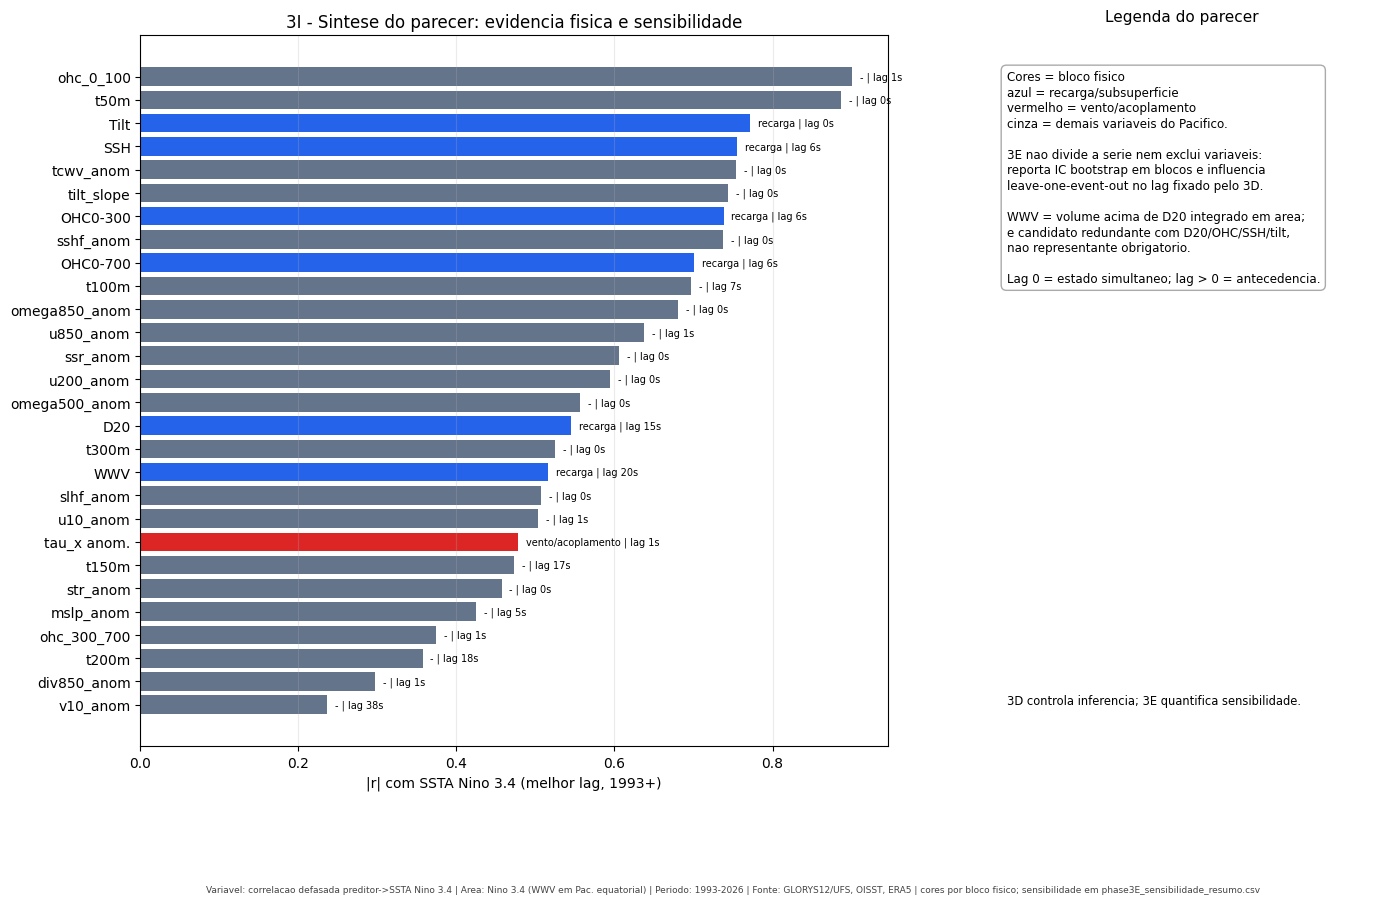

In [5]:
# Figura-sintese 1: ranking executivo e legenda de conceitos.
conc2 = conc.sort_values('abs_r', ascending=False)
fig, (ax, ax_note) = plt.subplots(1, 2, figsize=(15.8, max(7.2, .33*len(conc2))), gridspec_kw={'width_ratios':[2.35, 1.15]})
block_colors = {'recarga/subsuperficie':'#2563eb', 'vento/acoplamento':'#dc2626', '-':'#64748b'}
y = np.arange(len(conc2))
ax.barh(y, conc2['abs_r'], color=conc2['bloco'].map(block_colors).fillna('#64748b'))
ax.set_yticks(y)
ax.set_yticklabels(conc2['rotulo'])
for i, (_, r) in enumerate(conc2.iterrows()):
    ax.text(r['abs_r']+.01, i, f"{r['bloco'].replace('recarga/subsuperficie','recarga')} | lag {int(r['lag_semanas'])}s", va='center', fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('|r| com SSTA Nino 3.4 (melhor lag, 1993+)')
ax.set_title('3I - Sintese do parecer: evidencia fisica e sensibilidade')
ax.grid(axis='x', alpha=.25)
ax_note.axis('off')
ax_note.set_title('Legenda do parecer', fontsize=11, pad=10)
legend_txt = (
    'Cores = bloco fisico\n'
    'azul = recarga/subsuperficie\n'
    'vermelho = vento/acoplamento\n'
    'cinza = demais variaveis do Pacifico.\n\n'
    '3E nao divide a serie nem exclui variaveis:\n'
    'reporta IC bootstrap em blocos e influencia\n'
    'leave-one-event-out no lag fixado pelo 3D.\n\n'
    'WWV = volume acima de D20 integrado em area;\n'
    'e candidato redundante com D20/OHC/SSH/tilt,\n'
    'nao representante obrigatorio.\n\n'
    'Lag 0 = estado simultaneo; lag > 0 = antecedencia.'
)
ax_note.text(0.02, 0.95, legend_txt, fontsize=8.55, va='top', ha='left', linespacing=1.25, bbox=dict(boxstyle='round,pad=.45', fc='white', ec='0.65', alpha=.95))
ax_note.text(0.02, 0.055, '3D controla inferencia; 3E quantifica sensibilidade.', fontsize=8.3, va='bottom', ha='left')
u.stamp_caption(fig, variavel='correlacao defasada preditor->SSTA Nino 3.4', area='Nino 3.4 (WWV em Pac. equatorial)', periodo='1993-2026', fonte='GLORYS12/UFS, OISST, ERA5', extra='cores por bloco fisico; sensibilidade em phase3E_sensibilidade_resumo.csv')
u.save_fig(fig, '3I1_sintese_parecer.png')
plt.show()


[figura] data\processed\figures\fase3\3I2_antecipacao_pico.png


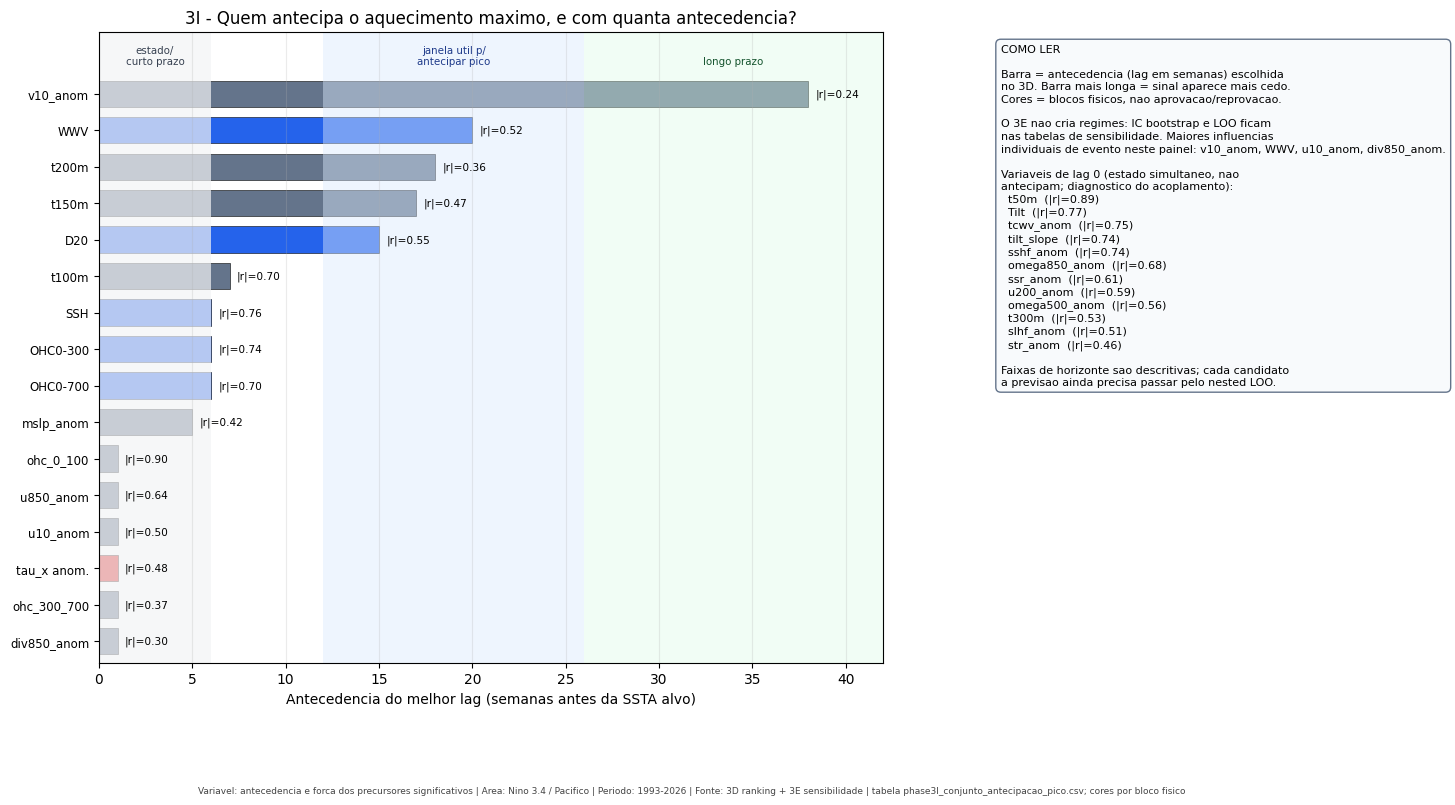

In [6]:
# ---------- 3I2 redesenhado: barras horizontais legiveis ----------
d = antecip.copy()
lead = d[d['lag_semanas'] > 0].sort_values(['lag_semanas','abs_r'], ascending=[True, True])
simult = d[d['lag_semanas'] == 0].sort_values('abs_r', ascending=False)
fig, (ax, ax_note) = plt.subplots(1, 2, figsize=(15.8, max(8.2, .42*len(lead))), gridspec_kw={'width_ratios':[2.5, 1.05]})
y = np.arange(len(lead))
cores = lead['bloco'].map(block_colors).fillna('#64748b')
ax.barh(y, lead['lag_semanas'], color=cores, edgecolor='k', lw=.4, height=.72)
ax.set_yticks(y)
ax.set_yticklabels(lead['rotulo'], fontsize=8.5)
for yi, (_, r) in zip(y, lead.iterrows()):
    ax.text(r['lag_semanas'] + 0.4, yi, f"|r|={r['abs_r']:.2f}", va='center', fontsize=7.6)
ax.axvspan(0, 6, color='#f3f4f6', alpha=.7, lw=0)
ax.axvspan(12, 26, color='#dbeafe', alpha=.45, lw=0)
ax.axvspan(26, 42, color='#dcfce7', alpha=.4, lw=0)
ax.text(3, len(lead)-0.2, 'estado/\ncurto prazo', ha='center', fontsize=7.4, color='#374151')
ax.text(19, len(lead)-0.2, 'janela util p/\nantecipar pico', ha='center', fontsize=7.4, color='#1e3a8a')
ax.text(34, len(lead)-0.2, 'longo prazo', ha='center', fontsize=7.4, color='#14532d')
ax.set_xlim(0, 42)
ax.set_ylim(-0.6, len(lead)+0.7)
ax.set_xlabel('Antecedencia do melhor lag (semanas antes da SSTA alvo)')
ax.set_title('3I - Quem antecipa o aquecimento maximo, e com quanta antecedencia?')
ax.grid(axis='x', alpha=.25)
ax_note.axis('off')
sim_txt = '\n'.join(f"  {r['rotulo']}  (|r|={r['abs_r']:.2f})" for _, r in simult.head(12).iterrows())
mais_influenciadas = ', '.join(lead.nlargest(4, 'loo_max_delta_r')['rotulo'].tolist())
ax_note.text(0.02, 0.98,
    'COMO LER\n\n'
    'Barra = antecedencia (lag em semanas) escolhida\n'
    'no 3D. Barra mais longa = sinal aparece mais cedo.\n'
    'Cores = blocos fisicos, nao aprovacao/reprovacao.\n\n'
    'O 3E nao cria regimes: IC bootstrap e LOO ficam\n'
    'nas tabelas de sensibilidade. Maiores influencias\n'
    f'individuais de evento neste painel: {mais_influenciadas}.\n\n'
    'Variaveis de lag 0 (estado simultaneo, nao\n'
    'antecipam; diagnostico do acoplamento):\n' + sim_txt + '\n\n'
    'Faixas de horizonte sao descritivas; cada candidato\n'
    'a previsao ainda precisa passar pelo nested LOO.',
    transform=ax_note.transAxes, fontsize=8.0, va='top', ha='left', linespacing=1.3,
    bbox={'boxstyle': 'round,pad=0.45', 'facecolor': '#f8fafc', 'edgecolor': '#64748b'})
u.stamp_caption(fig, variavel='antecedencia e forca dos precursores significativos', area='Nino 3.4 / Pacifico', periodo='1993-2026', fonte='3D ranking + 3E sensibilidade', extra='tabela phase3I_conjunto_antecipacao_pico.csv; cores por bloco fisico')
u.save_fig(fig, '3I2_antecipacao_pico.png')
plt.show()


[tabela] data\processed\parquet\statistics\phase3I_skill_por_variavel.csv
[tabela] data\processed\parquet\statistics\phase3I_modelos_candidatos.csv


[tabela] data\processed\parquet\statistics\phase3I_skill_horizontes.csv


[tabela] data\processed\parquet\statistics\phase3I_nested_loo_eventos.csv
[tabela] data\processed\parquet\statistics\phase3I_nested_loo_metricas.csv
[tabela] data\processed\parquet\statistics\phase3I_nested_loo_selecao.csv
[tabela] data\processed\parquet\statistics\phase3I_projecao_pico_2026.csv


[figura] data\processed\figures\fase3\3I3_previsao_condicional_nested.png
projecao: 1.93 C | IC95 0.985 2.875 | modelo ohc300_20w | nested skill 0.319


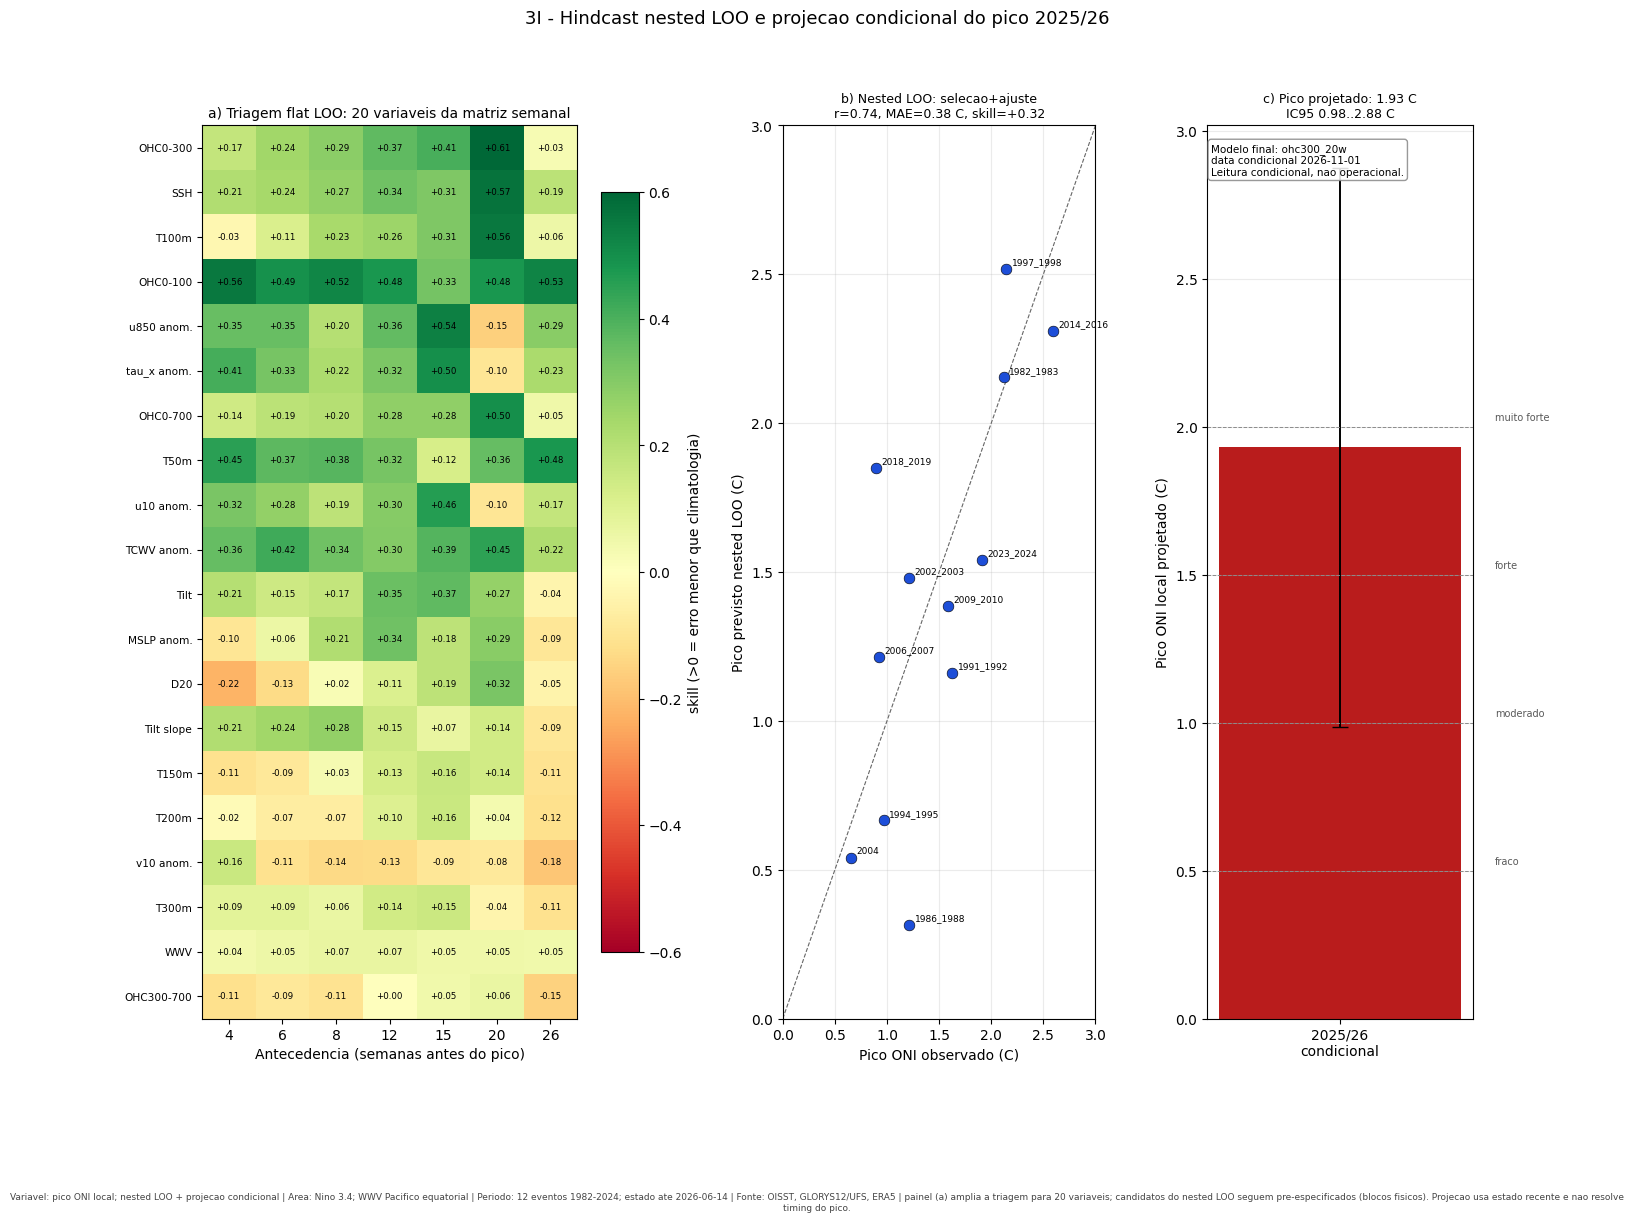

[tabela] data\processed\parquet\statistics\phase3I_referencias_metodologicas.csv


WindowsPath('C:/DEV/NINO26/data/processed/parquet/statistics/phase3I_referencias_metodologicas.csv')

In [7]:
ev_h = u.events_noaa()
# ---------- 3I3: triagem com conjunto AMPLIADO de variaveis ----------
LEADS = [4, 6, 8, 12, 15, 20, 26]
CAND = ['d20_m','wwv','ohc_0_300','ohc_0_700','ssh_m','tilt_m','tau_x_anom_nino34_pa',
        'ohc_0_100','ohc_300_700','tilt_slope','t50m','t100m','t150m','t200m','t300m',
        'u10_anom','u850_anom','tcwv_anom','v10_anom','mslp_anom']
EXTRA_LBL = {'ohc_0_100':'OHC0-100','ohc_300_700':'OHC300-700','tilt_slope':'Tilt slope','t50m':'T50m','t100m':'T100m','t150m':'T150m','t200m':'T200m','t300m':'T300m','u10_anom':'u10 anom.','u850_anom':'u850 anom.','tcwv_anom':'TCWV anom.','v10_anom':'v10 anom.','mslp_anom':'MSLP anom.'}
rows = []
for v in CAND:
    for L in LEADS:
        _, met = u.loo_peak_hindcast(w, ev_h, {v: L})
        met.update({'variavel': v, 'rotulo': EXTRA_LBL.get(v, u.var_label(v, short=True)), 'lead_semanas': L})
        rows.append(met)
skill_var = pd.DataFrame(rows)[['variavel','rotulo','lead_semanas','n_eventos','r_loo','mae_loo_c','mae_climatologia_c','skill_vs_climatologia']]
u.save_table(skill_var, 'phase3I_skill_por_variavel.csv', index=False)
melhor = skill_var.sort_values('skill_vs_climatologia', ascending=False).groupby('variavel').head(1).sort_values('skill_vs_climatologia', ascending=False)
antec = skill_var.query('skill_vs_climatologia > 0').groupby('variavel')['lead_semanas'].max().rename('antecedencia_max_util_sem')
melhor = melhor.merge(antec, on='variavel', how='left')

candidates = u.candidate_peak_specs(horizons=(8, 12, 15, 20, 26))
cand_public = pd.DataFrame([{k:v for k,v in c.items() if k != 'spec'} for c in candidates])
u.save_table(cand_public, 'phase3I_modelos_candidatos.csv', index=False)
best_protocol, skill_h_all = u.select_best_spec_by_loo(w, ev_h, candidates)
skill_h = skill_h_all[['modelo','familia','horizonte_sem','variaveis','n_preditores','n_eventos','r_loo','mae_loo_c','mae_climatologia_c','skill_vs_climatologia','residuo_std_c']]
u.save_table(skill_h, 'phase3I_skill_horizontes.csv', index=False)
nested_res, nested_met, nested_sel = u.nested_loo_peak_hindcast(w, ev_h, candidates)
u.save_table(nested_res, 'phase3I_nested_loo_eventos.csv', index=False)
u.save_table(pd.DataFrame([nested_met]), 'phase3I_nested_loo_metricas.csv', index=False)
u.save_table(nested_sel, 'phase3I_nested_loo_selecao.csv', index=False)

H_STAR = int(best_protocol['horizonte_sem'])
spec_star = best_protocol['spec']
res_flat_star, met_flat_star = u.loo_peak_hindcast(w, ev_h, spec_star)
proj = u.fit_and_project_peak(w, ev_h, spec_star)
last_w = pd.to_datetime(proj['ultima_semana_dado'])
proj['antecedencia_min_sem'], proj['antecedencia_max_sem'] = int(min(spec_star.values())), int(max(spec_star.values()))
proj['janela_pico_projetada_ini'] = str((last_w + pd.Timedelta(weeks=int(min(spec_star.values())))).date())
proj['janela_pico_projetada_fim'] = str((last_w + pd.Timedelta(weeks=int(max(spec_star.values())))).date())
if proj['janela_pico_projetada_ini'] == proj['janela_pico_projetada_fim']:
    proj['janela_pico_projetada_label'] = f"data condicional {proj['janela_pico_projetada_ini']}"
else:
    proj['janela_pico_projetada_label'] = f"janela condicional {proj['janela_pico_projetada_ini']} a {proj['janela_pico_projetada_fim']}"
ic = 1.96 * (nested_met['residuo_std_c'] if np.isfinite(nested_met['residuo_std_c']) else met_flat_star['residuo_std_c'])
proj_row = {**{k: v for k, v in proj.items() if k != 'valores_atuais'},
            'modelo': best_protocol['modelo'], 'familia': best_protocol['familia'], 'variaveis': best_protocol['variaveis'],
            'horizonte_sem': H_STAR,
            'r_loo': nested_met['r_nested_loo'], 'mae_loo_c': nested_met['mae_nested_loo_c'],
            'skill_vs_climatologia': nested_met['skill_vs_climatologia'],
            'r_flat_loo_modelo_final': met_flat_star['r_loo'], 'mae_flat_loo_modelo_final_c': met_flat_star['mae_loo_c'],
            'ic95_baixo_c': round(proj['pico_projetado_c'] - ic, 3), 'ic95_alto_c': round(proj['pico_projetado_c'] + ic, 3),
            'validacao': nested_met['protocolo'],
            'leitura': 'projecao condicional exploratoria: amplitude do pico assumindo que o estado atual e precursor de um pico ~H semanas a frente'}
u.save_table(pd.DataFrame([proj_row]), 'phase3I_projecao_pico_2026.csv', index=False)

fig = plt.figure(figsize=(16.4, max(7.2, 0.42*len(melhor)+3.2)))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1.0, 0.85], wspace=0.32)
axa = fig.add_subplot(gs[0])
piv = skill_var.pivot(index='rotulo', columns='lead_semanas', values='skill_vs_climatologia')
piv = piv.reindex(list(melhor['rotulo']))
im = axa.imshow(piv.values, cmap='RdYlGn', vmin=-0.6, vmax=0.6, aspect='auto')
axa.set_xticks(range(len(piv.columns))); axa.set_xticklabels(piv.columns)
axa.set_yticks(range(len(piv.index))); axa.set_yticklabels(piv.index, fontsize=7.6)
for ii in range(piv.shape[0]):
    for jj in range(piv.shape[1]):
        axa.text(jj, ii, f'{piv.values[ii, jj]:+.2f}', ha='center', va='center', fontsize=6.2, color='k')
axa.set_xlabel('Antecedencia (semanas antes do pico)')
axa.set_title(f'a) Triagem flat LOO: {len(CAND)} variaveis da matriz semanal', fontsize=10)
fig.colorbar(im, ax=axa, shrink=0.85, label='skill (>0 = erro menor que climatologia)')
axb = fig.add_subplot(gs[1])
col_pred = 'oni_pico_prev_nested_loo_c'
axb.scatter(nested_res['oni_pico_obs_c'], nested_res[col_pred], s=60, color='#1d4ed8', edgecolor='k', lw=.4, zorder=3)
for _, rr in nested_res.iterrows():
    axb.annotate(str(rr['event_id']).replace('el_nino_oisst_',''), (rr['oni_pico_obs_c'], rr[col_pred]), xytext=(4,3), textcoords='offset points', fontsize=6.5)
lims = [0, max(3.0, float(nested_res[['oni_pico_obs_c', col_pred]].max().max())+0.3)]
axb.plot(lims, lims, color='0.4', lw=.8, ls='--')
axb.set_xlim(lims); axb.set_ylim(lims)
axb.set_xlabel('Pico ONI observado (C)'); axb.set_ylabel('Pico previsto nested LOO (C)')
axb.set_title(f"b) Nested LOO: selecao+ajuste\nr={nested_met['r_nested_loo']:.2f}, MAE={nested_met['mae_nested_loo_c']:.2f} C, skill={nested_met['skill_vs_climatologia']:+.2f}", fontsize=9)
axb.grid(alpha=.25)
axc = fig.add_subplot(gs[2])
axc.bar([0], [proj['pico_projetado_c']], color='#b91c1c', width=.5)
axc.errorbar([0], [proj['pico_projetado_c']], yerr=[[ic],[ic]], color='k', capsize=6, lw=1.4)
for lim, nome in [(0.5,'fraco'),(1.0,'moderado'),(1.5,'forte'),(2.0,'muito forte')]:
    axc.axhline(lim, color='0.55', lw=.7, ls='--')
    axc.text(0.32, lim+0.02, nome, fontsize=7, color='0.35')
axc.set_xticks([0]); axc.set_xticklabels(['2025/26\ncondicional'])
axc.set_ylabel('Pico ONI local projetado (C)')
axc.set_title(f"c) Pico projetado: {proj['pico_projetado_c']:.2f} C\nIC95 {proj_row['ic95_baixo_c']:.2f}..{proj_row['ic95_alto_c']:.2f} C", fontsize=9)
axc.grid(axis='y', alpha=.25)
u.add_note(axc, f"Modelo final: {best_protocol['modelo']}\n{proj_row['janela_pico_projetada_label']}\nLeitura condicional, nao operacional.", loc='upper left')
fig.suptitle('3I - Hindcast nested LOO e projecao condicional do pico 2025/26', fontsize=13)
u.stamp_caption(fig, variavel='pico ONI local; nested LOO + projecao condicional', area='Nino 3.4; WWV Pacifico equatorial', periodo=f"12 eventos 1982-2024; estado ate {proj['ultima_semana_dado']}", fonte='OISST, GLORYS12/UFS, ERA5', extra='painel (a) amplia a triagem para 20 variaveis; candidatos do nested LOO seguem pre-especificados (blocos fisicos). Projecao usa estado recente e nao resolve timing do pico.')
u.save_fig(fig, '3I3_previsao_condicional_nested.png')
print('projecao:', proj['pico_projetado_c'], 'C | IC95', proj_row['ic95_baixo_c'], proj_row['ic95_alto_c'], '| modelo', best_protocol['modelo'], '| nested skill', nested_met['skill_vs_climatologia'])
plt.show()

refs = pd.DataFrame([
    {'uso':'recarga ENSO','referencia':'Jin, F.-F. (1997), equatorial ocean recharge paradigm for ENSO','url':'https://doi.org/10.1175/1520-0469(1997)054<0811:AEORPF>2.0.CO;2'},
    {'uso':'WWV/D20/vento como precursores fisicos','referencia':'Meinen & McPhaden (2000), Observations of Warm Water Volume Changes...','url':'https://www.pmel.noaa.gov/pubs/outstand/mein2119/mein2119.shtml'},
    {'uso':'verificacao hindcast/skill','referencia':'WMO Lead Centre, Verification Hindcast / SVSLRF','url':'https://wmolc.org/contents/index/Verification%2BHindcast'},
    {'uso':'skill ENSO por hindcasts/modelos','referencia':'Barnston et al. (2012), Skill of Real-Time Seasonal ENSO Model Predictions','url':'https://doi.org/10.1175/BAMS-D-11-00111.1'},
    {'uso':'controle de vies de selecao','referencia':'Ambroise & McLachlan (2002), Selection bias in gene extraction...','url':'https://ambroise.cloud/publications/arti_ambroise2002selection/index.html'},
    {'uso':'controle de vies de selecao','referencia':'Cawley & Talbot (2010), On over-fitting in model selection...','url':'https://www.jmlr.org/papers/v11/cawley10a.html'},
    {'uso':'pico como faixa (phase-locking, ONI 3 meses)','referencia':'docs/PICO_FAIXA_BIBLIOGRAFIA.md (compilacao NINO-BRASIL 2026)','url':''},
])
u.save_table(refs, 'phase3I_referencias_metodologicas.csv', index=False)


**Veredito integrado (Pacifico).** A Fase 3 entrega quatro leituras encadeadas: (i) **diagnostico** - o bloco de recarga/subsuperficie (D20, SSH, OHC, WWV, tilt) descreve o reservatorio que permite a amplificacao da SSTA, com `tau_x_anom` como acoplamento vento-superficie; (ii) **rigor** - o 3D controla N_eff, IC95 e FDR; (iii) **sensibilidade** - o 3E usa bootstrap em blocos e leave-one-event-out, sem breakpoint ou gate; (iv) **validacao do protocolo** - o nested LOO avalia a regra completa de escolher modelo/horizonte dentro do treino e prever o evento retido. A projecao 2025/26 segue explicitamente **condicional e exploratoria**, nao operacional. WWV permanece candidato classico de recarga, derivado de D20 e redundante com outras medidas do bloco; nao recebe privilegio nem ressalva baseada em um corte de 2010.


In [8]:
# exporta texto integrado atualizado para o parecer
entra = ', '.join(conc['variavel'].tolist())
mais_influenciadas = ', '.join(conc.nlargest(5, 'loo_max_delta_r')['variavel'].tolist())
prioritarios = ', '.join(antecip[antecip['interpreta_para_2026'].str.startswith('candidato')]['variavel'].tolist())
estado = est.iloc[0]
linhas = []
for _, r in media.iterrows():
    linhas.append(f"`{r['grupo']}`: n={int(r['n_eventos'])}, pico ONI medio {r['oni_pico_medio_c']} C, duracao media {r['duracao_media_estacoes_oni']} estacoes, crescimento medio {r['crescimento_medio_c_mes']} C/mes e decaimento medio {r['decaimento_medio_c_mes']} C/mes.")
classes_txt = '\n\n'.join(linhas)
texto = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4. O bloco de recarga/subsuperficie (D20/OHC/SSH/WWV/tilt) domina a interpretacao do aquecimento maximo; `tau_x_anom_nino34_pa` representa acoplamento vento-superficie. Candidatos com antecedencia >=12 semanas, ainda sujeitos ao nested LOO: {prioritarios or 'nenhum'}.

## Definicao NOAA/ONI local
Evento El Nino = media movel de 3 meses da SSTA Nino 3.4 >=+0.5 C por pelo menos 5 estacoes moveis sobrepostas. Intensidade = pico dessa media: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. O pico e delimitado tambem como FAIXA (meses com ONI >= pico-0.1 C; ver docs/PICO_FAIXA_BIBLIOGRAFIA.md e phase3B_faixa_pico_eventos.csv). O CPC/NOAA tambem exige evidencia atmosferica; aqui o acoplamento e avaliado por proxy local (`tau_x_anom_nino34_pa`), nao como declaracao oficial.

## Relacoes e sensibilidade
Relacoes que passaram pelo controle inferencial do 3D: {entra}. O 3E nao divide a serie nem cria um segundo filtro: reporta IC por bootstrap movel e influencia leave-one-event-out. Maiores influencias individuais observadas: {mais_influenciadas}. Isso orienta cautela, nao exclusao automatica nem alegacao de regime.

WWV = volume acima da isoterma de 20 C integrado em 5S-5N, 120E-80W. E um candidato derivado de D20 e parcialmente redundante com D20/OHC/SSH/tilt; nao e representante obrigatorio do bloco.

## Classes NOAA
{classes_txt}

## Estado 2025/26
Ultimo dado diario OISST: {estado['ultimo_dia']}, SSTA diaria {estado['ssta_diaria_c']} C. Leitura: {estado['leitura']}.

## Hindcast nested LOO e projecao condicional
Metodo adotado: candidatos fisicos pre-especificados (`phase3I_modelos_candidatos.csv`), loop interno LOO para escolher modelo/horizonte no treino, loop externo LOO para prever o evento retido. Resultado do protocolo completo: r_nested_loo={proj_row['r_loo']}, MAE={proj_row['mae_loo_c']} C, skill vs climatologia={proj_row['skill_vs_climatologia']}. Modelo final selecionado em todo o historico: {proj_row['modelo']} ({proj_row['variaveis']}) no horizonte de {proj_row['horizonte_sem']} semanas. Projecao condicional do pico 2025/26: {proj_row['pico_projetado_c']} C (IC95 {proj_row['ic95_baixo_c']} a {proj_row['ic95_alto_c']} C), {proj_row['janela_pico_projetada_label']}. Isto estima amplitude condicionada ao estado recente; ainda nao e previsao operacional de timing.

## Referencias metodologicas
- Jin (1997) e Meinen & McPhaden (2000): paradigma de recarga ENSO, D20/WWV/vento/SST.
- McPhaden (2012): variacao decadal do lead WWV em torno da virada do seculo; nao fundamenta corte em 2010.
- WMO SVSLRF e Barnston et al. (2012): verificacao por hindcast e skill contra climatologia.
- Ambroise & McLachlan (2002) e Cawley & Talbot (2010): selecao de modelo deve ocorrer dentro do loop de treino para evitar vies otimista.
- docs/PICO_FAIXA_BIBLIOGRAFIA.md: fundamentacao do pico como faixa (phase-locking, ONI de 3 meses, verificacao sazonal).

## Proxima decisao
A Fase 3 entrega uma avaliacao preditiva exploratoria defensavel por nested LOO. A Fase 5 deve transformar isso em previsao operacional com walk-forward temporal, embargo, barreira de primavera, baseline de persistencia amortecida e previsao simultanea de timing + amplitude (janela/faixa de pico, nao data pontual).
"""
out = u.STATS / 'phase3I_interpretacao_integrada.md'
out.write_text(texto, encoding='utf-8')
print(f"[texto] {out.relative_to(u.ROOT)}")


[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Timmermann, A., et al. (2018). El Niño-Southern Oscillation complexity. *Nature*, 559, 535-545. https://doi.org/10.1038/s41586-018-0252-6
2. Cai, W., et al. (2020). Climate impacts of ENSO on South America. *Nat. Rev. Earth Environ.*, 1, 215-231. https://doi.org/10.1038/s43017-020-0040-3
3. Cawley, G. C., & Talbot, N. L. C. (2010). On Over-fitting in Model Selection... *JMLR*, 11, 2079-2107. https://www.jmlr.org/papers/v11/cawley10a.html

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.